# CC-EDU Evaluaiton and demo

Implementation of CC‑EDU and conflict-aware rule restriction
from the paper:

    "Quantifying and Mitigating Epistemic Uncertainty
     in Local Rule-Based Explanations"

This code follows the extensional interpretation of rules used
throughout the paper: a rule R_i is treated not only as a
syntactic object (feature constraints), but as the *empirical
coverage set* C_i ⊆ X — the subset of dataset instances that
satisfy it.

Key concepts implemented here:

    • Empirical coverage   C_i  (Definition 1, Section 3.1)
    • Neighborhood-conditioned contradiction  contr_i(R_i, R_j)
    • Structural Disagreement (Equation 2)
    • CC‑EDU metric (Equation 3)
    • Directional disagreement region D_ij (Equation 4)
    • Local rule restriction via decision stumps (Section 3.1)
    • Preservation of explained instanc
## Structure
  * `cc_edu.py` -- implementation of CC_EDU metric and rule restriction algorihtm
  * `utils.py` -- plotting, utilities for rule collectione during restriction


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re
from lux.lux import LUX
from collections import defaultdict
from sklearn import svm
from sklearn.metrics import f1_score
from cc_edu import *
from utils import *



In [4]:
import shap
shap.__version__

'0.41.0'

# Evaluation

In [5]:
# ────────────────────────────────────────────────

# Step 1: Load data – keep as DataFrame
dsname="iris" #iris, pima, wine, breast_cancer,  openml_sonar,openml_credit_g

X_df,y=load_classification_dataset(name=dsname, n_samples=100, n_features=20, n_classes=2)
X_train_df, X_test_df, y_train_real, y_test_real = train_test_split(
    X_df, y, test_size=0.3, random_state=42
)

# Step 2: Scale — but keep DataFrame structure
scaler = StandardScaler()
X_train_scaled_df = pd.DataFrame(
    scaler.fit_transform(X_train_df),
    columns=X_train_df.columns,
    index=X_train_df.index
)

X_test_scaled_df = pd.DataFrame(
    scaler.transform(X_test_df),
    columns=X_test_df.columns,
    index=X_test_df.index
)

# Also create NumPy versions only where strictly needed (e.g. UMAP, NearestNeighbors)
X_test_scaled_np = X_test_scaled_df.to_numpy()

# Step 3: Train model (can use scaled DataFrame or NumPy – RandomForest accepts both)
mw = RandomForestClassifier(n_estimators=100, random_state=42)#svm.SVC(probability=True)#RandomForestClassifier(n_estimators=100, random_state=42)
mw.fit(X_train_scaled_df, y_train_real)
print(f"Model Accuracy: {mw.score(X_test_scaled_df, y_test_real):.2f}")

y_test = mw.predict(X_test_scaled_df)
y_train = mw.predict(X_train_scaled_df)

Model Accuracy: 1.00


## Contour

In [6]:
X_test_scaled_df.shape

(45, 4)

In [7]:
import numpy as np
from sklearn.metrics import f1_score
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import os

locality=min(100,X_test_scaled_df.shape[0]-1)

# how much of Ri coverage is contradictory
RESTRICTION_THRESHOLD = 0.01 

# Threshold for visualizing disagreement edges
OVERLAP_THRESHOLD = 0.01

avg = "micro"

# Parameter grids
locality_values = np.arange(
    5, 
    min(100, X_test_scaled_df.shape[0] - 1) + 1,
    5
)
lux_locality_values = np.linspace(0.01, 0.2, 15)

# Result containers
f1_all_grid = np.zeros((len(lux_locality_values), len(locality_values)))
edu_avg_grid = np.zeros((len(lux_locality_values), len(locality_values)))

f1_all_grid_r = np.zeros((len(lux_locality_values), len(locality_values)))
edu_avg_grid_r = np.zeros((len(lux_locality_values), len(locality_values)))




def worker(task):
    """
    One grid-point computation.
    """
    i, j, lux_locality, locality = task

    # --- CC-EDU ---
    print(f'Starting {task}')
    edu_scores, lux,rules_total_exp,knn_indices = compute_cc_edu_lux(
        X_train_scaled_df,
        y_train,
        X_test_scaled_df,
        mw,
        k=locality,
        lux_locallity=lux_locality,
        overlap_threshold=OVERLAP_THRESHOLD
    )
    edu_avg = np.mean(edu_scores)

    # --- Prediction ---
    y_pred, covered = predict_with_lux_rules(
        X_test_scaled_df,
        rules_total_exp
    )

    y_pred = np.array([int(p) if p is not None else -1 for p in y_pred])
    mask = (covered > 0) & (y_pred != None)

    f1 = f1_score(
        y_test,
        y_pred,
        average=avg
    )

    restricted_rules,_,_ = restrict_rules(rules_total_exp, X_test_scaled_df, OVERLAP_THRESHOLD, RESTRICTION_THRESHOLD, knn_indices=knn_indices)

    y_pred_r, covered = predict_with_lux_rules(
        X_test_scaled_df,
        restricted_rules
    )

    y_pred_r = np.array([int(p) if p is not None else -1 for p in y_pred_r])
    mask = (covered > 0) & (y_pred_r != None)

    f1_r = f1_score(
        y_test,
        y_pred_r,
        average=avg
    )
    edu_scores_r,_ = compute_cc_edu(
        [parse_lux_rule(r) for r in restricted_rules],
        X_test_scaled_df,
        k=locality,
        overlap_threshold=OVERLAP_THRESHOLD
    )
    
    edu_avg_r = np.mean(edu_scores_r)
    
    print(f'Completing {task} with edu {edu_avg}')

    return i, j, edu_avg, f1, f1_r, edu_avg_r


# Build task list
tasks = [
    (i, j, lux_locality, locality)
    for i, lux_locality in enumerate(lux_locality_values)
    for j, locality in enumerate(locality_values)
]

# Use ~170 cores (or slightly less to keep OS alive)
n_workers = min(40, os.cpu_count())

print(f"Running with {n_workers} workers, total tasks: {len(tasks)}")

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    futures = [executor.submit(worker, task) for task in tasks]

    for future in tqdm(as_completed(futures), total=len(futures), desc="Grid search"):
        i, j, edu_avg, f1,f1_r, edu_avg_r = future.result()
        edu_avg_grid[i, j] = edu_avg
        f1_all_grid[i, j] = f1
        edu_avg_grid_r[i, j] = edu_avg_r
        f1_all_grid_r[i, j] = f1_r




# ... run your grid search to fill these arrays ...
# edu_avg_grid, f1_all_grid, edu_avg_grid_r, f1_all_grid_r = ...
dnsname = "grid-data"   # folder name grouping a set of datasets
base_dir = "./results"  # local or Google Drive

saved_path = save_grid_results(
    base_dir=base_dir,
    dnsname=dnsname,
    dsname=dsname,
    edu_avg_grid=edu_avg_grid,
    f1_all_grid=f1_all_grid,
    edu_avg_grid_r=edu_avg_grid_r,
    f1_all_grid_r=f1_all_grid_r,
)
print(f"Saved: {saved_path}")



Running with 40 workers, total tasks: 120
Starting (0, 0, 0.01, 5)Starting (0, 1, 0.01, 10)Starting (0, 3, 0.01, 20)Starting (0, 2, 0.01, 15)


Grid search:   0%|          | 0/120 [00:00<?, ?it/s]


Starting (0, 5, 0.01, 30)

Starting (0, 7, 0.01, 40)Starting (0, 4, 0.01, 25)Starting (1, 4, 0.02357142857142857, 25)Starting (0, 6, 0.01, 35)Starting (1, 7, 0.02357142857142857, 40)Starting (1, 6, 0.02357142857142857, 35)
Starting (1, 5, 0.02357142857142857, 30)
Starting (2, 4, 0.037142857142857144, 25)Starting (2, 5, 0.037142857142857144, 30)


Starting (1, 1, 0.02357142857142857, 10)Starting (2, 6, 0.037142857142857144, 35)
Starting (1, 2, 0.02357142857142857, 15)Starting (2, 7, 0.037142857142857144, 40)Starting (2, 1, 0.037142857142857144, 10)Starting (2, 0, 0.037142857142857144, 5)Starting (2, 2, 0.037142857142857144, 15)Starting (2, 3, 0.037142857142857144, 20)
Starting (3, 2, 0.05071428571428572, 15)
Starting (3, 1, 0.05071428571428572, 10)Starting (3, 4, 0.05071428571428572, 25)Starting (3, 3, 0.05071428571428572, 20)

Starting (4, 0, 0.06428571428571428, 5)Starting (3, 0, 0.05071428571428572, 5)
Starting (1, 3, 0.02357142857142857, 20)Starting (4, 1, 0.06428571428571428, 10)


Grid search:   1%|          | 1/120 [00:01<02:50,  1.44s/it]


Starting (5, 1, 0.07785714285714285, 10)
Completing (0, 0, 0.01, 5) with edu 0.03916049382716049
Starting (5, 2, 0.07785714285714285, 15)
Completing (4, 0, 0.06428571428571428, 5) with edu 0.012641975308641975
Starting (5, 3, 0.07785714285714285, 20)
Completing (2, 0, 0.037142857142857144, 5) with edu 0.03916049382716049
Starting (5, 4, 0.07785714285714285, 25)
Completing (2, 1, 0.037142857142857144, 10) with edu 0.059629629629629616
Starting (5, 5, 0.07785714285714285, 30)

...

Completing (13, 7, 0.18642857142857144, 40) with edu 0.0022534722222222222


Grid search:  99%|█████████▉| 119/120 [00:15<00:00,  3.38it/s]

Completing (14, 7, 0.2, 40) with edu 0.002277777777777778


Grid search: 100%|██████████| 120/120 [00:16<00:00,  7.49it/s]

Saved: ./results/grid-data/iris.npz


In [8]:
L, Lux = np.meshgrid(locality_values, lux_locality_values)

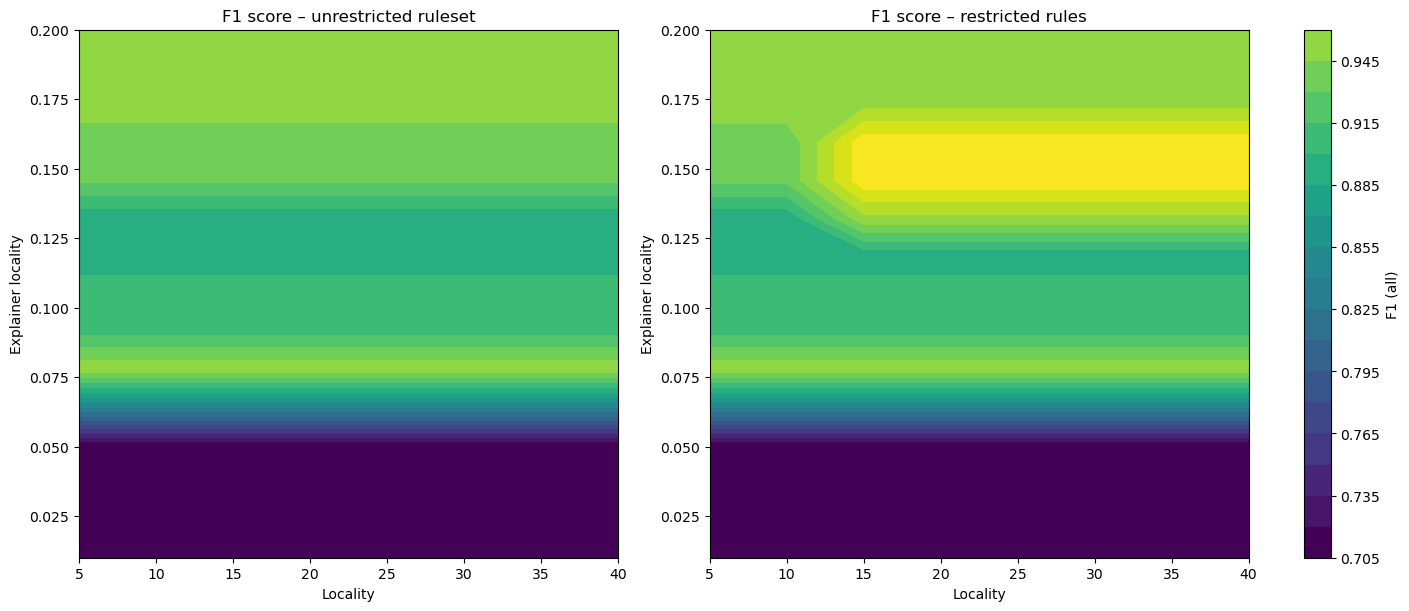

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Compute shared color range
vmin = min(f1_all_grid.min(), f1_all_grid_r.min())
vmax = max(f1_all_grid.max(), f1_all_grid_r.max())

# Use constrained_layout to manage spacing more robustly
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# --- First subplot ---
cont1 = axes[0].contourf(L, Lux, f1_all_grid, levels=20, vmin=vmin, vmax=vmax)
axes[0].set_title("F1 score – unrestricted ruleset")
axes[0].set_xlabel("Locality")
axes[0].set_ylabel("Explainer locality")

# --- Second subplot ---
cont2 = axes[1].contourf(L, Lux, f1_all_grid_r, levels=20, vmin=vmin, vmax=vmax)
axes[1].set_title("F1 score – restricted rules")
axes[1].set_xlabel("Locality")
axes[1].set_ylabel("Explainer locality")

# --- One shared colorbar outside (right) ---
# 'ax=axes' attaches it to both; 'pad' controls distance; 'fraction' the size of the bar
cbar = fig.colorbar(cont1, ax=axes, location='right', fraction=0.046, pad=0.04)
cbar.set_label("F1 (all)")

# Save combined figure
plt.savefig(
    f"f1_score_locality_vs_lux_{dsname}_combined_same_scale.pdf",
    format="pdf", bbox_inches="tight"
)
plt.show()

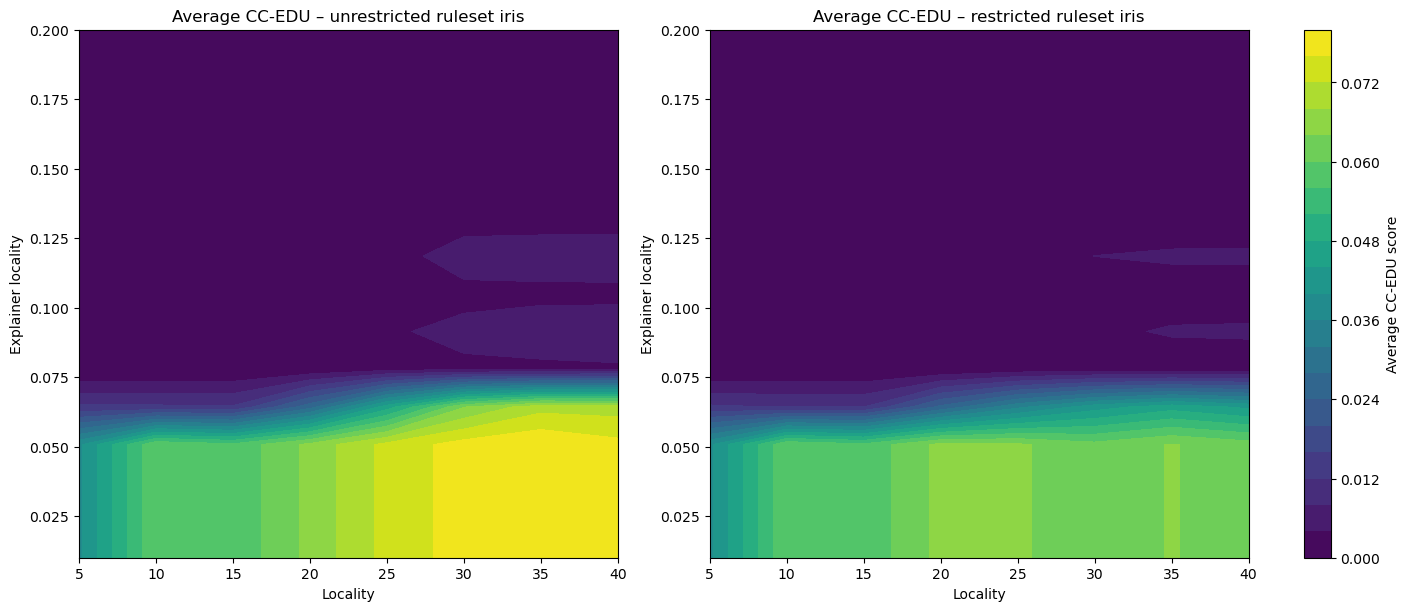

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Shared color range across both grids
vmin = min(edu_avg_grid.min(), edu_avg_grid_r.min())
vmax = max(edu_avg_grid.max(), edu_avg_grid_r.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# --- First subplot ---
cont1 = axes[0].contourf(
    L, Lux, edu_avg_grid,
    levels=20, vmin=vmin, vmax=vmax
)
axes[0].set_title(f"Average CC-EDU – unrestricted ruleset {dsname}")
axes[0].set_xlabel("Locality")
axes[0].set_ylabel("Explainer locality")

# --- Second subplot ---
cont2 = axes[1].contourf(
    L, Lux, edu_avg_grid_r,
    levels=20, vmin=vmin, vmax=vmax
)
axes[1].set_title(f"Average CC-EDU – restricted ruleset {dsname}")
axes[1].set_xlabel("Locality")
axes[1].set_ylabel("Explainer locality")

# --- Shared colorbar on the right, outside ---
cbar = fig.colorbar(
    cont1, ax=axes,
    location="right",
    fraction=0.046,
    pad=0.04
)
cbar.set_label("Average CC-EDU score")


# Save figure
plt.savefig(
    f"cc_edu_score_locality_vs_lux_{dsname}_combined_same_scale.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

## Histograms

In [11]:
%%time
locality=min(100,X_test_scaled_df.shape[0]-1)
lux_locallity=0.055

# how much of Ri coverage is contradictory
RESTRICTION_THRESHOLD = 0.01 

# Threshold for visualizing disagreement edges
OVERLAP_THRESHOLD = 0.05



# Threshold for visualizing disagreement edges

edu_scores,lux, rules_total_exp,_= compute_cc_edu_lux(X_train_scaled_df,y_train,X_test_scaled_df, mw,k=locality, lux_locallity=lux_locallity, overlap_threshold=OVERLAP_THRESHOLD)
print("CC-EDU Scores (sample):", edu_scores[:5])

y_pred, covered = predict_with_lux_rules(X_test_scaled_df, rules_total_exp)
avg='micro'

mask = (covered > 0) & (y_pred != None)
y_pred = np.array([int(p) for p in y_pred])

results = {
    "f1_all": f1_score(y_test, y_pred, average=avg),
    "f1_covered": f1_score(y_test[mask], y_pred[mask], average=avg),
    "average_coverage_per_rule": covered.mean(),
    "n_test": len(y_test),
    "n_covered": mask.sum()
}

results

CC-EDU Scores (sample): [0.08712121 0.00744949 0.         0.13759193 0.08712121]
CPU times: user 3.22 s, sys: 110 ms, total: 3.33 s
Wall time: 3.24 s


{'f1_all': 0.8444444444444444,
 'f1_covered': 0.8444444444444444,
 'average_coverage_per_rule': 0.4967901234567902,
 'n_test': 45,
 'n_covered': 45}

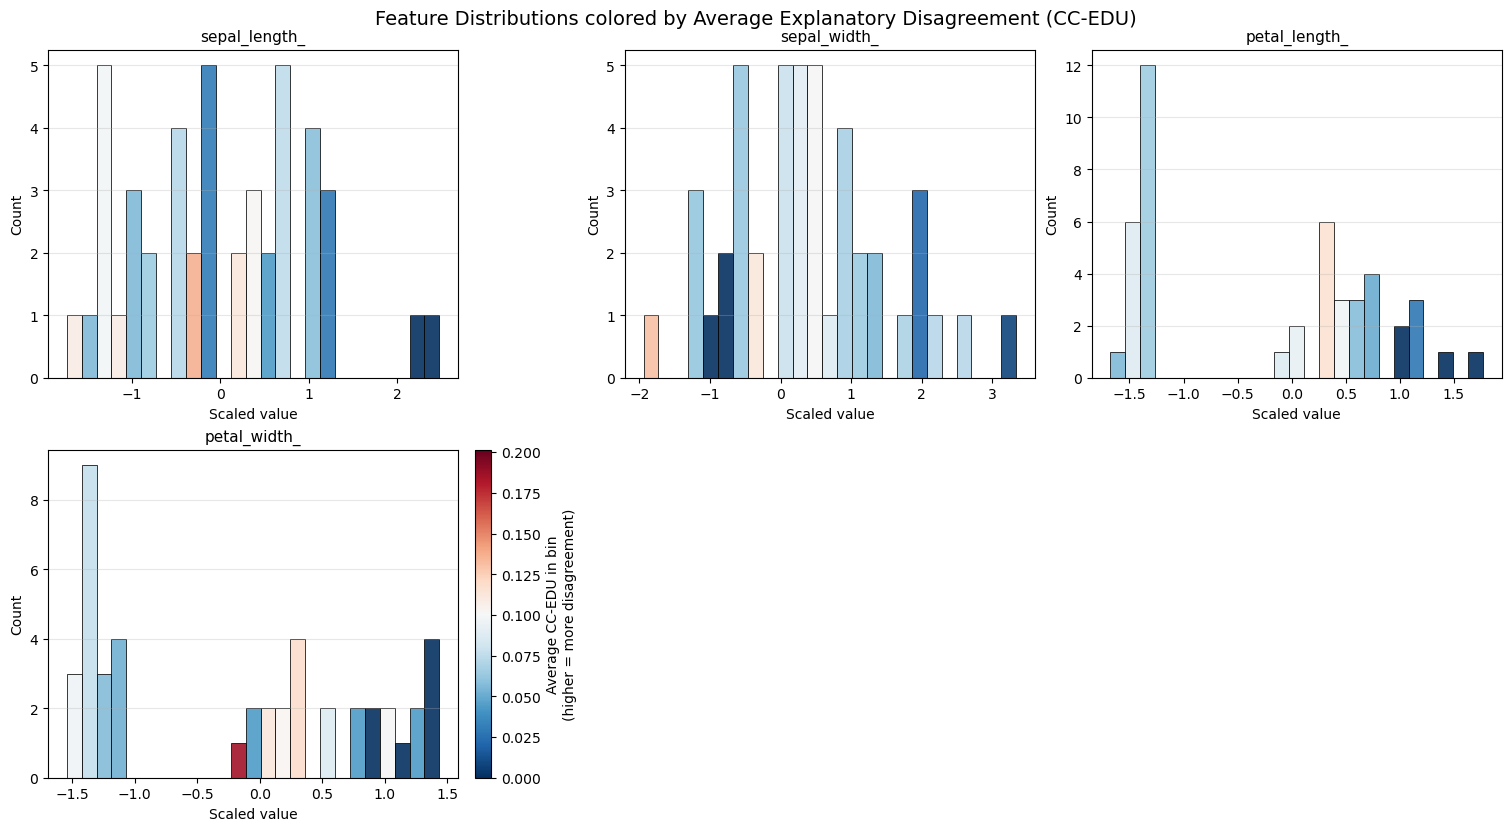

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ────────────────────────────────────────────────────────────────
#   Prepare combined dataframe with EDU scores
# ────────────────────────────────────────────────────────────────

df_vis = X_test_scaled_df.copy()
df_vis['cc_edu'] = edu_scores

# ────────────────────────────────────────────────────────────────
#   Plot one histogram per feature with EDU-colored bars
# ────────────────────────────────────────────────────────────────

n_features = len(X_test_scaled_df.columns)
n_cols = min(3, n_features)                # e.g. 3 plots per row
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), 
                         sharey=False, constrained_layout=True)

axes = axes.flat if n_features > 1 else [axes]

for i, feature in enumerate(X_test_scaled_df.columns):
    ax = axes[i]
    
    # ── Create histogram with bins, also get bin edges and counts ──
    counts, bin_edges, patches = ax.hist(
        df_vis[feature], 
        bins=25, 
        density=False, 
        alpha=0.9, 
        color='lightgray',  # fallback
        edgecolor='black',
        linewidth=0.6
    )
    
    # ── Compute average EDU per bin ──
    bin_indices = np.digitize(df_vis[feature], bin_edges) - 1   # 0-based
    bin_indices = np.clip(bin_indices, 0, len(bin_edges)-2)     # avoid overflow
    
    avg_edu_per_bin = np.zeros(len(counts))
    for b in range(len(counts)):
        mask = (bin_indices == b)
        if mask.sum() > 0:
            avg_edu_per_bin[b] = df_vis.loc[mask, 'cc_edu'].mean()
        else:
            avg_edu_per_bin[b] = 0
    
    # ── Color patches according to average EDU ──
    norm = plt.Normalize(0, max(edu_scores.max(), 0.01))   # avoid div-by-zero
    cmap = plt.cm.RdBu_r                                   # red=high disagreement
    
    for patch, avg_edu in zip(patches, avg_edu_per_bin):
        color = cmap(norm(avg_edu))
        patch.set_facecolor(color)
    
    # ── Add colorbar (only once, on last plot or separate) ──
    if i == n_features - 1:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Average CC-EDU in bin\n(higher = more disagreement)')
    
    ax.set_title(feature, fontsize=11)
    ax.set_xlabel("Scaled value")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3, axis='y')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions colored by Average Explanatory Disagreement (CC-EDU)", 
             fontsize=14, y=1.02)

plt.savefig("feature_histograms_by_edu.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ──────────────────────────────────────────────
# Compute high-disagreement edges
# ──────────────────────────────────────────────


# Precompute contradictions between test instances
high_disagree_edges = []  # list of (i,j) tuples
high_disagree_rules = []

for i in range(len(rules_total_exp)):
    rule_i_list = rules_total_exp[i]
    if not rule_i_list: 
        continue
    rule_i = parse_lux_rule(rule_i_list)  # Take first rule as representative
    for j in range(i+1, len(rules_total_exp)):
        rule_j_list = rules_total_exp[j]
        if not rule_j_list:
            continue
        rule_j = parse_lux_rule(rule_j_list) 
        
        
        if rule_i and rule_j:
            if is_contradictory(rule_i, rule_j, X_test_scaled_df, min_overlap=OVERLAP_THRESHOLD):
                high_disagree_edges.append((i, j))
                high_disagree_rules.append((rule_i,rule_j))



In [14]:
high_disagree_rules

[({'conditions': [], 'prediction': '1', 'confidence': 0.6666666666666666},
  {'conditions': [('petal_width_', '>=', 0.6912465989589691)],
   'prediction': '2',
   'confidence': 1.0}),
 ({'conditions': [], 'prediction': '1', 'confidence': 0.6666666666666666},
  {'conditions': [('sepal_length_', '<', -0.41341638565063477)],
   'prediction': '0',
   'confidence': 1.0}),
 ({'conditions': [], 'prediction': '1', 'confidence': 0.6666666666666666},
  {'conditions': [('petal_width_', '>=', 0.6912465989589691)],
   'prediction': '2',
   'confidence': 1.0}),
 ({'conditions': [], 'prediction': '1', 'confidence': 0.6666666666666666},
  {'conditions': [], 'prediction': '2', 'confidence': 0.5714285714285714}),
 ({'conditions': [], 'prediction': '1', 'confidence': 0.6666666666666666},
  {'conditions': [('petal_length_', '<', -0.8875385522842407)],
   'prediction': '0',
   'confidence': 1.0}),
 ({'conditions': [], 'prediction': '1', 'confidence': 0.6666666666666666},
  {'conditions': [('sepal_length_',

In [15]:
len(high_disagree_rules)

418

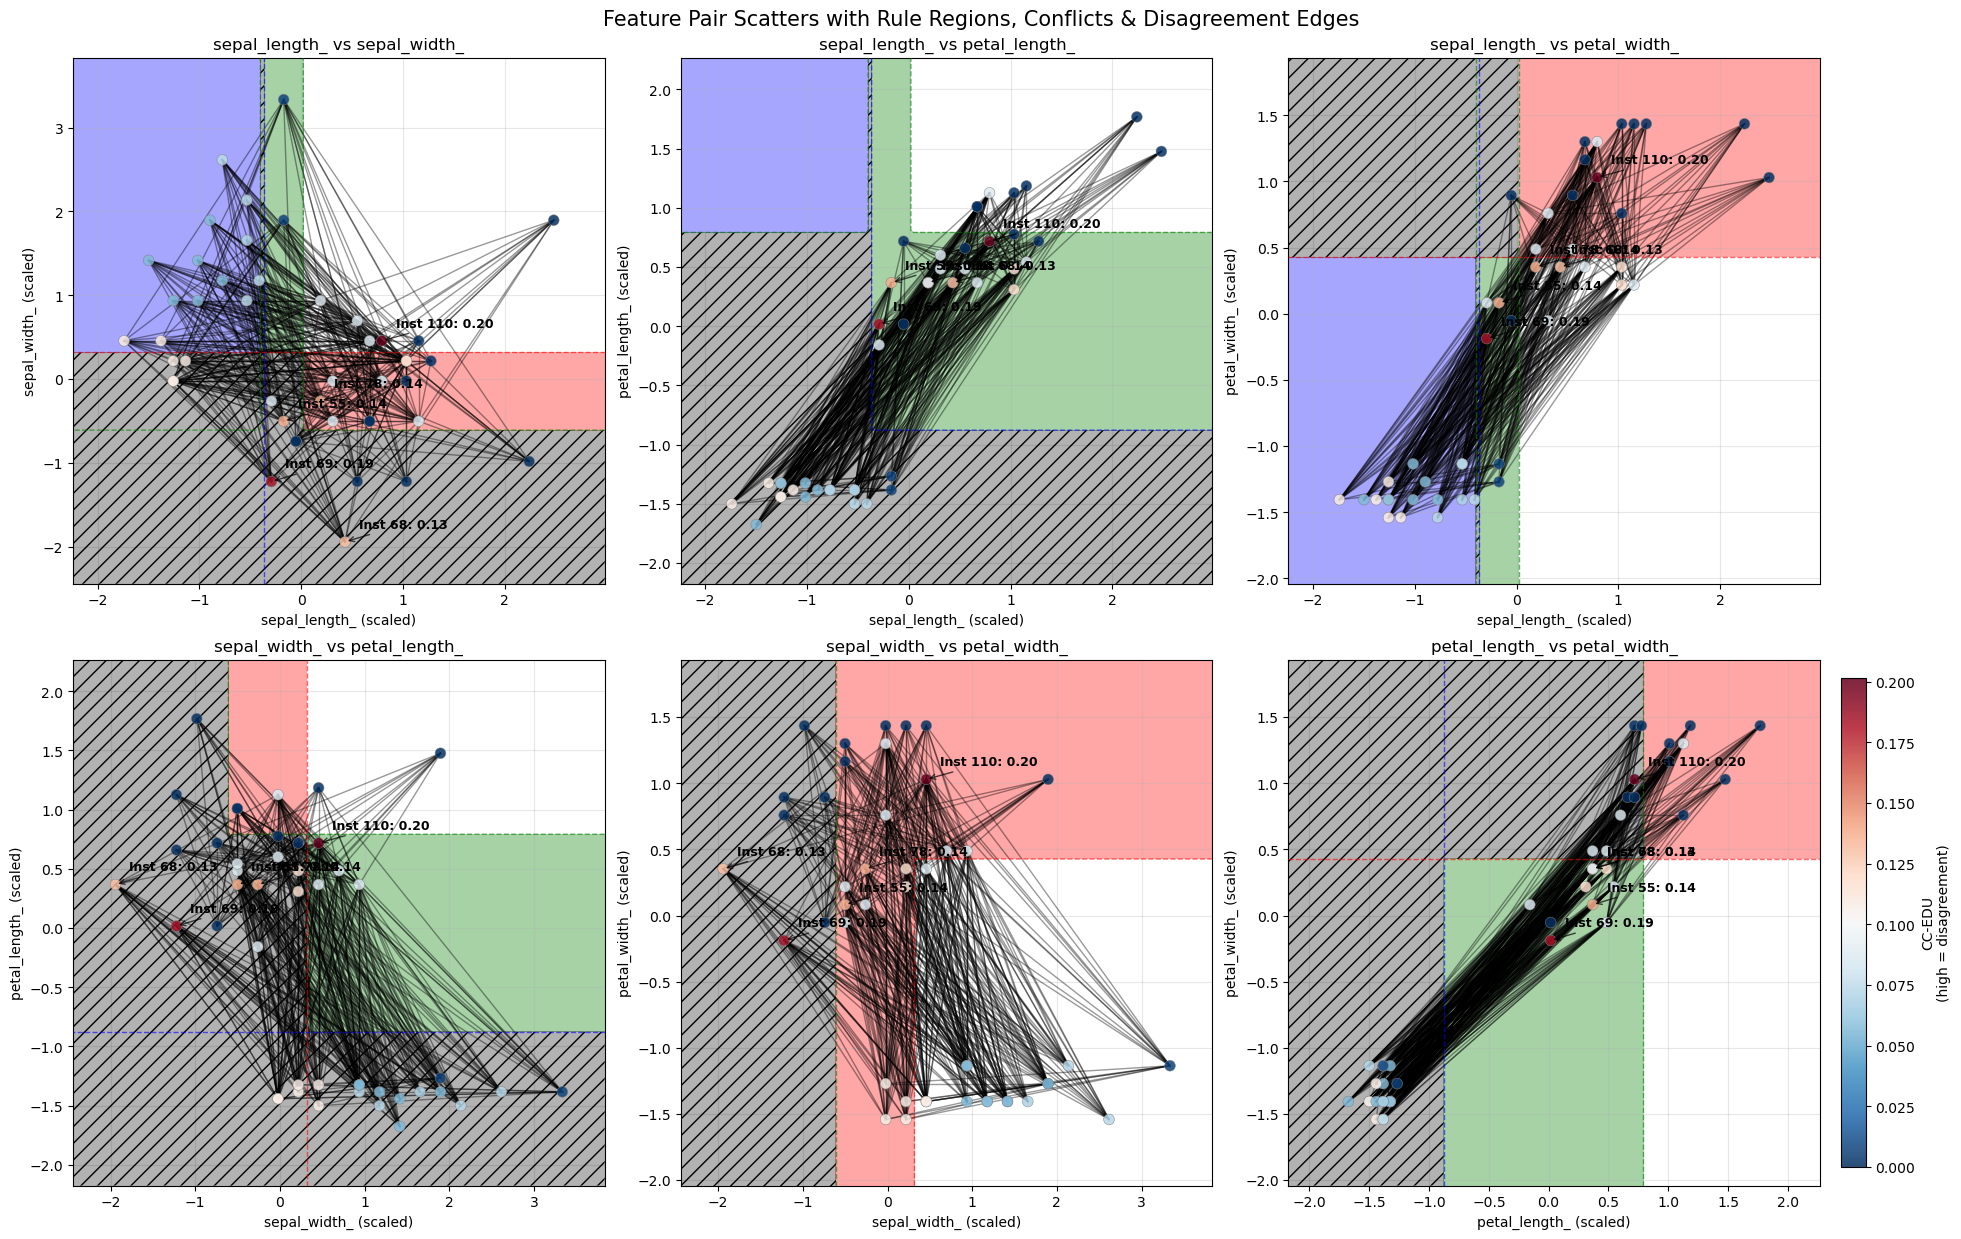

In [16]:

# ──────────────────────────────────────────────
# Modified plotting with edges
# ──────────────────────────────────────────────

df_plot = X_test_scaled_df.copy()
df_plot['cc_edu'] = edu_scores
df_plot['true_class'] = y_test
df_plot['index'] = df_plot.index  # For annotations

# Top disagreed instances (top 5 by EDU)
top_disagreed = df_plot.nlargest(5, 'cc_edu').index.tolist()

feature_pairs = list(combinations(X_test_scaled_df.columns, 2))
n_pairs = len(feature_pairs)
n_cols = min(3, n_pairs)
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6 * n_rows),
                         constrained_layout=True)

axes = axes.flatten()
norm_edu = plt.Normalize(vmin=0, vmax=max(edu_scores.max(), 0.01))
cmap_edu = 'RdBu_r'
class_colors = {'0': 'blue', '1': 'green', '2': 'red'}  # Adjust for your classes


all_rules = []
for i, rule_group in enumerate(rules_total_exp):
    for sublist in rule_group:
        for r in sublist:
            all_rules.append({
                'rule_dict': r['rule'],
                'prediction': r['prediction'],
                'confidence': float(r['confidence']),
                'edu': edu_scores[i],
                'instance_idx': i
            })

for idx, (feat_x, feat_y) in enumerate(feature_pairs):
    ax = axes[idx]
    
    # Scatter points colored by CC-EDU
    sc_points = ax.scatter(
        df_plot[feat_x], df_plot[feat_y],
        c=df_plot['cc_edu'], cmap=cmap_edu, norm=norm_edu,
        alpha=0.85, s=60, edgecolor='gray', linewidth=0.4, zorder=4
    )
    
    # Draw edges for high-disagreement pairs
    for i, j in high_disagree_edges:
        x_vals = [df_plot.iloc[i][feat_x], df_plot.iloc[j][feat_x]]
        y_vals = [df_plot.iloc[i][feat_y], df_plot.iloc[j][feat_y]]
        ax.plot(x_vals, y_vals, color='black', alpha=0.4, linewidth=1.0, zorder=2)

    
    # ── Meshgrid, coverage, conflict regions as before ─────────
    x_min, x_max = df_plot[feat_x].min() - 0.5, df_plot[feat_x].max() + 0.5
    y_min, y_max = df_plot[feat_y].min() - 0.5, df_plot[feat_y].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150),
                         np.linspace(y_min, y_max, 150))
    
    coverage = {pred: np.zeros_like(xx) for pred in class_colors.keys()}
    for rule_info in all_rules:
        rule_dict = rule_info['rule_dict']
        pred = rule_info['prediction']
        conf = rule_info['confidence']
        involved_feats = set(rule_dict.keys())
        if not {feat_x, feat_y} & involved_feats:
            continue
        mask = np.vectorize(lambda x, y: satisfies_rule(rule_dict, feat_x, feat_y, x, y))(xx, yy)
        coverage[pred] += mask.astype(float) * conf
    
    conflict = np.zeros_like(xx)
    for pred in coverage:
        conflict += (coverage[pred] > 0).astype(int)
    
    for pred, cov in coverage.items():
        single_mask = (cov > 0) & (conflict == 1)
        if np.any(single_mask):
            ax.contourf(xx, yy, single_mask, levels=[0.5, 1], colors=class_colors[pred],
                        alpha=0.35, zorder=1)
    
    mixed_mask = (conflict >= 2)
    if np.any(mixed_mask):
        ax.contourf(xx, yy, mixed_mask, levels=[0.5, 1], colors='black',
                    alpha=0.3, hatches=['//'], zorder=2)
    
    for pred, cov in coverage.items():
        ax.contour(xx, yy, cov > 0, levels=[0.5], colors=class_colors[pred],
                   linewidths=1.0, alpha=0.6, linestyles='dashed', zorder=3)
    
    # Annotate top disagreed instances
    for inst_idx in top_disagreed:
        if inst_idx not in df_plot.index:
            continue
    
        pos = df_plot.index.get_loc(inst_idx)  # label → position
    
        x_pos = df_plot.iloc[pos][feat_x]
        y_pos = df_plot.iloc[pos][feat_y]
        edu_val = df_plot.iloc[pos]['cc_edu']
    
        ax.annotate(
            f"Inst {inst_idx}: {edu_val:.2f}",
            (x_pos, y_pos),
            xytext=(10, 10),
            textcoords='offset points',
            fontsize=9,
            color='black',
            weight='bold',
            arrowprops=dict(arrowstyle='->', color='black', alpha=0.7),
            zorder=5
        )
        
    ax.set_title(f"{feat_x} vs {feat_y}", fontsize=12)
    ax.set_xlabel(f"{feat_x} (scaled)")
    ax.set_ylabel(f"{feat_y} (scaled)")
    ax.grid(True, alpha=0.3)
    
    if idx == n_pairs - 1:
        cbar = fig.colorbar(sc_points, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('CC-EDU\n(high = disagreement)')

# Hide unused
for ax in axes[n_pairs:]:
    ax.set_visible(False)

fig.suptitle("Feature Pair Scatters with Rule Regions, Conflicts & Disagreement Edges",
             fontsize=15, y=1.02)

plt.savefig("scatter_with_disagreement_edges.png", dpi=180, bbox_inches='tight')
plt.show()


In [17]:
from matplotlib.colors import Normalize
rules_parsed = [parse_lux_rule(r) for r in rules_total_exp if True or r[0][0]['rule']!={}]
# Instance view — interactive HTML
# plot_instance_parcoords(X_test_scaled_df, edu_scores, y_test, rules_parsed, k=5, edu_threshold=0.1)


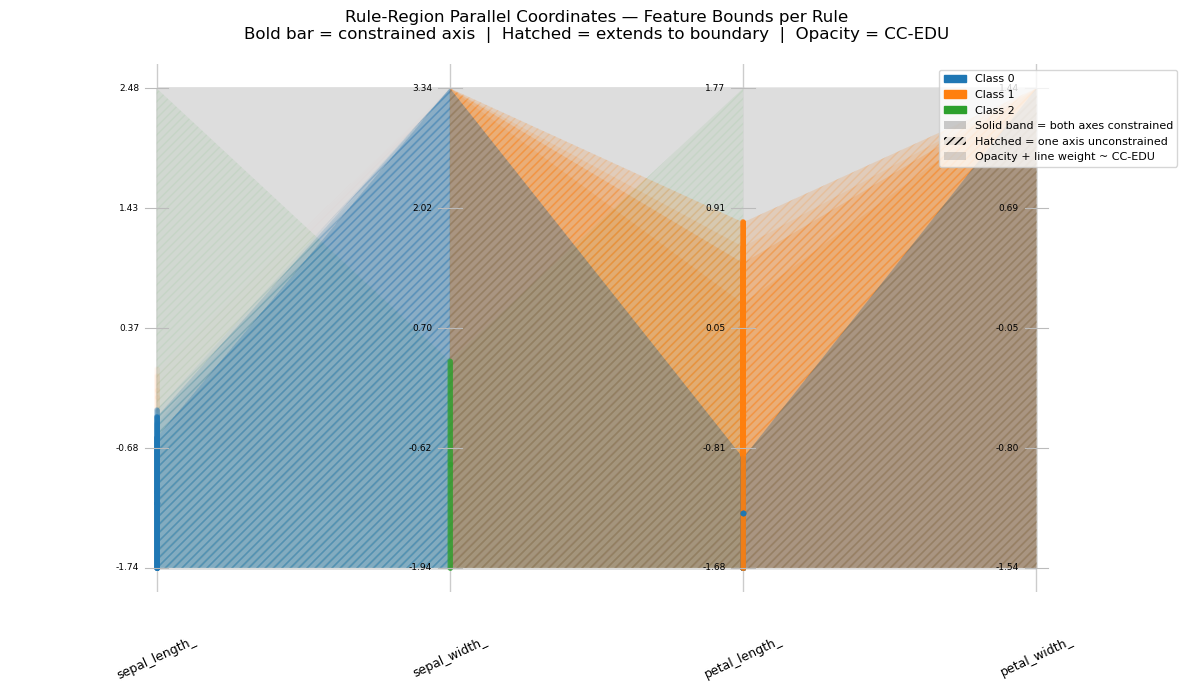

In [18]:
# Rule-region view — static, bands show feature coverage
plot_rule_parcoords(rules_parsed, edu_scores, X_test_scaled_df, savefile=dsname)

# Conflict-pair overlay — explicitly shows which rules fight each other


## Solve disagreaments

In [19]:
%%time
locality=19#min(100,X_test_scaled_df.shape[0]-1)
lux_locallity=0.03

# how much of Ri coverage is contradictory
RESTRICTION_THRESHOLD = 0.01  

OVERLAP_THRESHOLD = 0.01



# Threshold for visualizing disagreement edges

edu_scores,lux, rules_total_exp,knn_indices= compute_cc_edu_lux(X_train_scaled_df,y_train,X_test_scaled_df, mw,k=locality, lux_locallity=lux_locallity, overlap_threshold=OVERLAP_THRESHOLD)
print("CC-EDU Scores (sample):", edu_scores[:5])

y_pred, covered = predict_with_lux_rules(X_test_scaled_df, rules_total_exp)
avg='micro'

mask = (covered > 0) & (y_pred != None)
y_pred = np.array([int(p) for p in y_pred])

results = {
    "f1_all": f1_score(y_test, y_pred, average=avg),
    "f1_covered": f1_score(y_test[mask], y_pred[mask], average=avg),
    "average_coverage_per_rule": covered.mean(),
    "n_test": len(y_test),
    "n_covered": mask.sum()
}

results

CC-EDU Scores (sample): [0.12046784 0.         0.         0.09415205 0.12046784]
CPU times: user 1.39 s, sys: 15.8 ms, total: 1.41 s
Wall time: 1.39 s


{'f1_all': 0.7111111111111111,
 'f1_covered': 0.7111111111111111,
 'average_coverage_per_rule': 0.5797530864197532,
 'n_test': 45,
 'n_covered': 45}

In [20]:
restricted_rules,_,contradictions = restrict_rules(rules_total_exp, X_test_scaled_df, OVERLAP_THRESHOLD,RESTRICTION_THRESHOLD,knn_indices=knn_indices)#RESTRICTION_THRESHOLD)

In [21]:
y_pred, covered = predict_with_lux_rules(X_test_scaled_df, rules_total_exp)
y_pred_restricted, covered_restricted = predict_with_lux_rules(X_test_scaled_df, restricted_rules)

In [22]:
edu_scores,_ = compute_cc_edu(
        [parse_lux_rule(r) for r in rules_total_exp],
        X_test_scaled_df,
        k=locality,
        overlap_threshold=OVERLAP_THRESHOLD
    )
edu_scores.mean()

0.06061078622482132

In [23]:
edu_scores_r,_ = compute_cc_edu(
        [parse_lux_rule(r) for r in restricted_rules],
        X_test_scaled_df,
        k=locality,
        overlap_threshold=OVERLAP_THRESHOLD
    )
edu_scores_r.mean()

0.06061078622482132

In [24]:
avg='micro'

mask = (covered > 0) & (y_pred != None)
y_pred = np.array([int(p) for p in y_pred])

results = {
    "f1_all": f1_score(y_test, y_pred, average=avg),
    "f1_covered": f1_score(y_test[mask], y_pred[mask], average=avg),
    "average_coverage_per_rule": covered.mean(),
    "n_test": len(y_test),
    "n_covered": mask.sum()
}


In [25]:
avg='micro'

mask = (covered_restricted > 0) & (y_pred_restricted != None)
y_pred_restricted = np.array([int(p) if p is not None else -1 for p in y_pred_restricted])


results_restricted = {
    "f1_all": f1_score(y_test, y_pred_restricted, average=avg),
    "f1_covered": f1_score(y_test[mask], y_pred_restricted[mask], average=avg),
    "average_coverage_per_rule": covered.mean(),
    "n_test": len(y_test),
    "n_covered": mask.sum()
}


In [26]:
pd.DataFrame([results, results_restricted])

,f1_all,f1_covered,average_coverage_per_rule,n_test,n_covered
0,0.711111,0.711111,0.579753,45,45
1,0.711111,0.711111,0.579753,45,45


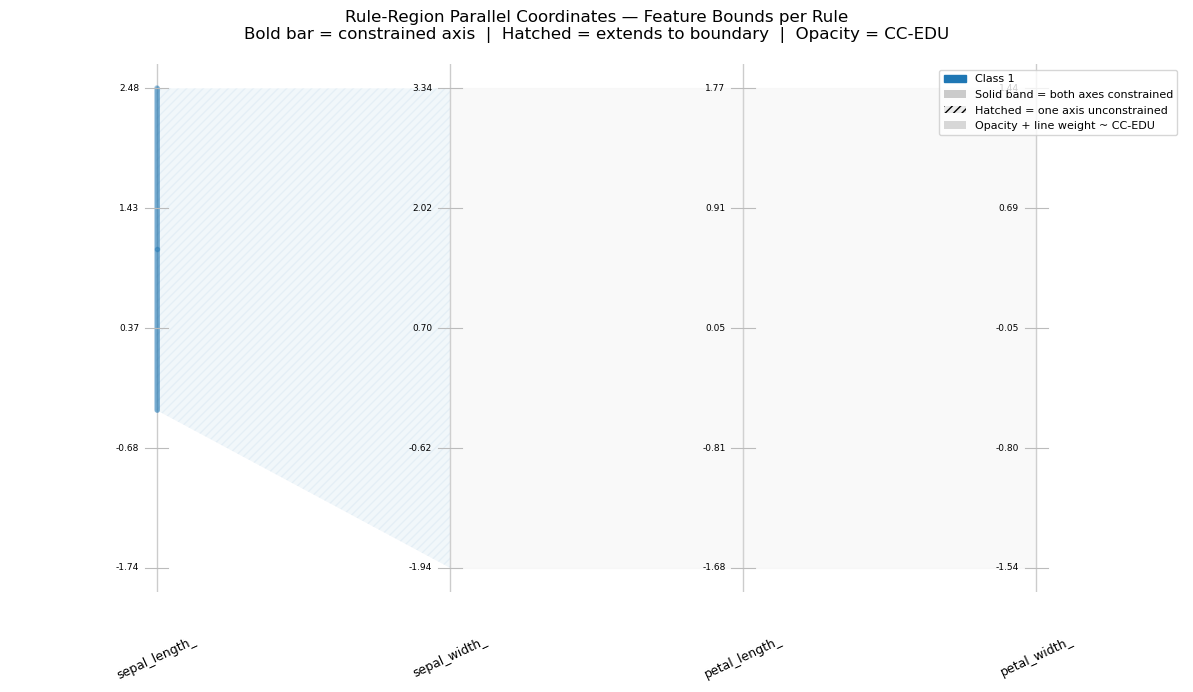

In [27]:
# Rule-region view — static, bands show feature coverage
restricted_rules_parsed = [parse_lux_rule(r) for r in [restricted_rules[1]] if True or r[0][0]['rule']!={}]
plot_rule_parcoords(restricted_rules_parsed, edu_scores_r, X_test_scaled_df)

# Conflict-pair overlay — explicitly shows which rules fight each other

In [28]:
for r, rr in zip(rules_total_exp, restricted_rules):
    print(f'RULE {r}\nRESTRICTED:{rr}\n========================================')

RULE [[{'rule': {}, 'prediction': '1', 'confidence': 0.6}]]
RESTRICTED:[[{'rule': {}, 'prediction': '1', 'confidence': 0.6}]]
RULE [[{'rule': {'sepal_length_': ['>=-0.35312649607658386']}, 'prediction': '1', 'confidence': 0.5}]]
RESTRICTED:[[{'rule': {'sepal_length_': ['>=-0.35312649607658386']}, 'prediction': '1', 'confidence': 0.5}]]
RULE [[{'rule': {'petal_width_': ['>=0.6912465989589691']}, 'prediction': '2', 'confidence': 1.0}]]
RESTRICTED:[[{'rule': {'petal_width_': ['>=0.6912465989589691']}, 'prediction': '2', 'confidence': 1.0}]]
RULE [[{'rule': {}, 'prediction': '1', 'confidence': 0.6}]]
RESTRICTED:[[{'rule': {}, 'prediction': '1', 'confidence': 0.6}]]
RULE [[{'rule': {}, 'prediction': '1', 'confidence': 0.6}]]
RESTRICTED:[[{'rule': {}, 'prediction': '1', 'confidence': 0.6}]]
RULE [[{'rule': {'sepal_length_': ['<-0.35312649607658386']}, 'prediction': '0', 'confidence': 1.0}]]
RESTRICTED:[[{'rule': {'sepal_length_': ['<-0.35312649607658386']}, 'prediction': '0', 'confidence': 1